<a href="https://colab.research.google.com/github/garam827/LLM_Study/blob/main/%EB%9E%AD%EA%B7%B8%EB%9E%98%ED%94%84_%EA%B8%B0%EB%B3%B8%EC%B1%97%EB%B4%87.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://github.com/saintdragon2/gpt_agent_2025_easyspub/blob/main/chap12/sec01/langgraph_simple_chatbot.ipynb

In [1]:
# %pip install langgraph
# %pip install langchain-openai

In [2]:
from google.colab import userdata

# OpenRouter API Key (assuming it's stored in Colab secrets)
OPENROUTER_API_KEY = userdata.get('OPEN_ROUTER')

In [9]:
from langchain_openai import ChatOpenAI

# 모델 초기화
model = ChatOpenAI(
    # model           = "google/gemma-4-26b-a4b-it:free", # Using gpt-4o-mini as an example model
    model           = "openai/gpt-oss-120b:free",
    openai_api_key  = OPENROUTER_API_KEY,
    openai_api_base = "https://openrouter.ai/api/v1"
)
model.invoke('안녕하세요!')

AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 70, 'total_tokens': 96, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 8, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 64, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b:free', 'system_fingerprint': None, 'id': 'gen-1776695946-LHnTBstKz34FMiqChu52', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dab54-ac35-76f2-80e3-05d0f6273103-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 70, 'output_tokens': 26, 'total_tokens': 96, 'input_token_details': {'audio': 0,

In [10]:
# 상태 정의 하기

from typing import Annotated            # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):	#①
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다.   #②
       'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.  #③
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    messages: Annotated[list[str], add_messages]	#②

# StateGraph 클래스를 사용하여 State 타입의 그래프를 생성합니다.
graph_builder = StateGraph(State) #④

In [11]:
# 노드 생성 하기

def generate(state: State):	#①
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.

    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리.
          형식은 {"messages": [응답 메시지]}입니다.
    """
    return {"messages": [model.invoke(state["messages"])]}	#②

graph_builder.add_node("generate", generate)	#③

In [12]:
# 엣지 설정하기

graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)

graph = graph_builder.compile()

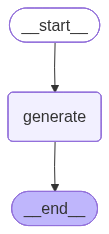

In [13]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [14]:
# 리스트에 문장 추가하기
response = graph.invoke({"messages": ["안녕하세요! 저는 김가람 입니다"]})

print(type(response))
response

<class 'dict'>


{'messages': [HumanMessage(content='안녕하세요! 저는 김가람 입니다', additional_kwargs={}, response_metadata={}, id='72c3e888-24c8-47c3-8f7f-baa0874e7167'),
  AIMessage(content='안녕하세요, 김가람님! 만나서 반갑습니다. 😊 오늘은 어떤 일로 도움을 드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 75, 'total_tokens': 118, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 9, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 64, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b:free', 'system_fingerprint': None, 'id': 'gen-1776695954-xvasSDUzvRg3ylRZoXl8', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dab54-cb2f-79e

In [15]:
# 이전 대화 내용에 새 메시지 추가하기
response["messages"].append("제 이름을 아시나요?")
graph.invoke(response)

{'messages': [HumanMessage(content='안녕하세요! 저는 김가람 입니다', additional_kwargs={}, response_metadata={}, id='72c3e888-24c8-47c3-8f7f-baa0874e7167'),
  AIMessage(content='안녕하세요, 김가람님! 만나서 반갑습니다. 😊 오늘은 어떤 일로 도움을 드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 75, 'total_tokens': 118, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 9, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 64, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b:free', 'system_fingerprint': None, 'id': 'gen-1776695954-xvasSDUzvRg3ylRZoXl8', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dab54-cb2f-79e

In [16]:
# 스트림 출력하기
inputs = {"messages": [("human", "한국과 일본의 관계에 대해 자세히 알려줘")]}
for chunk, _ in graph.stream(inputs, stream_mode="messages"):
    print(chunk.content, end="")

## 한국‑일본 관계 개요  

한국과 일본은 지리적으로 가깝고, 수천 년에 걸친 교류와 갈등을 반복해 온 **동북아시아의 핵심 양국**입니다. 오늘날 양국은 **경제·안보·문화·인적 교류**가 활발한 동시에, **역사·영토·군사·전략** 문제를 둘러싼 갈등도 여전히 존재합니다. 아래에서는 **역사적 흐름**, **현대 정치·외교**, **경제·무역**, **사회·문화 교류**, **주요 쟁점(위안부·강제징용·독도·역사교과서·안보협력)**, 그리고 **향후 전망**을 단계별·주제별로 정리하겠습니다.

---

## 1. 역사적 흐름

| 시기 | 주요 사건·관계 | 의미·영향 |
|------|----------------|-----------|
| **고대·삼국시대** (기원전 1세기~7세기) | 일본 서기(倭紀)·《삼국사기》 등에 한국 반도와 일본 열도 간 해상 교류 기록 | 초기 문화·기술 교류 (철기, 불교) |
| **통일신라·고려** (7~14세기) | 신라·고려와 일본(와카야마, 아시카가 등) 사이 사절 파송, 무역(금·은·동·염소) | 정치·문화 교류 확대, 일본 사절단이 신라·고려를 방문 |
| **임진왜란(1592‑1598)** | 일본(도요토미 히데요시) 의 침략, 조선·명·청 연합 방어 | 양국 관계가 극단적으로 악화, ‘북방정책’·‘대동아공영’ 의식 형성 |
| **청일전쟁·한일병합** (1894‑1910) | 일본의 한국 침략→1910년 한일 병합조약(강제 병합) | 35년간 식민통치 → 독립운동·민족주의 고양, 오늘날 갈등의 근원 |
| **광복·분단·전후** (1945‑1952) | 1945년 해방 → 1948년 남북 분단, 1950‑53년 한국전쟁 | 한·일 국교 정상화 지연 (1952년 ‘한·일 청구서’ 교환) |
| **국교 정상화** (1965) | 1965년 한일 기본조약 체결 → 외교·경제 관계 정상화 | 경제 협력 기반 구축, 동시에 ‘청구권·보상 문제’가 남음 |
| **1990‑2000년대** | 1995년 위안부 